In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
# Load the dataset
file = pd.read_csv("polynomial_data.csv")

# Display first few rows of dataset
print("Dataset Preview:")
print(file.head())
# Convert into NumPy arrays (important for ML operations)
x_train = file["x_train"].values
y_train = file["y_train"].values

# Check shape of data (for debugging)
print("\nShape of X:", x_train.shape)
print("Shape of Y:", y_train.shape)

Dataset Preview:
    x_train   y_train
0  0.000000  2.149014
1  0.033898  2.060216
2  0.067797  2.397696
3  0.101695  2.761994
4  0.135593  2.336534

Shape of X: (140,)
Shape of Y: (140,)


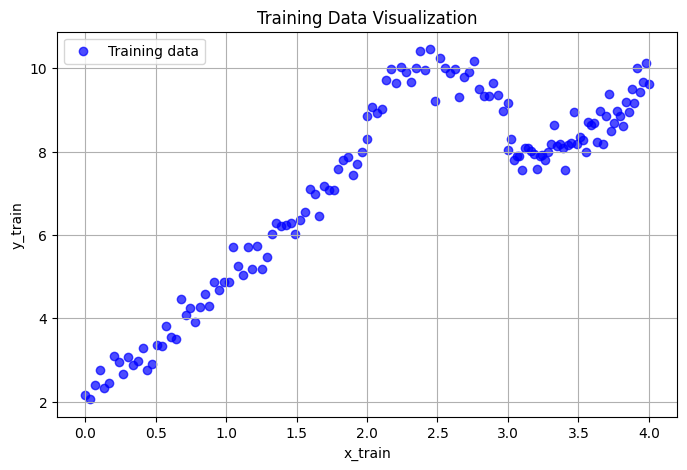

In [2]:
plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train, color="blue", label="Training data", alpha=0.7)
plt.xlabel("x_train")
plt.ylabel("y_train")
plt.title("Training Data Visualization")
plt.legend()
plt.grid(True)
plt.show()


In [3]:
# Normalize the data
x_train_scaled = (x_train-np.mean(x_train)) / (np.std(x_train) + 1e-8)

In [4]:
degree = 5
x_train_poly = np.ones((x_train.shape[0], degree))
for i in range(1, degree + 1):
    x_train_poly[:, i-1] = x_train_scaled ** i

In [5]:
y_train_reshaped = np.reshape(y_train, (-1, 1))

In [6]:
m = len(x_train)
iteration = 5000
#w = np.array([[1],[5],[3],[4],[5],])
w = np.random.randn(degree, 1)
learning_rate = 0.05
cost_ = []
b = 0
for _ in range(iteration):
    # yp = w @ x_train + w @ (x_train**2) + w @ (x_train**3) 
    yp =  x_train_poly @ w + b

    cost = np.mean((yp - y_train_reshaped) ** 2) / 2
    cost_.append(cost)
    

    dw = (np.transpose(x_train_poly) @ (yp - y_train_reshaped)) / m
    db = np.sum((yp - y_train_reshaped)) / m
    
    w = w - learning_rate*dw
    b = b - learning_rate*db
    
    if _ % 500 == 0:
        print(f"Iteration {_}: Cost = {cost}")


Iteration 0: Cost = 61.47742810430362
Iteration 500: Cost = 0.258656306457342
Iteration 1000: Cost = 0.16636128354049576
Iteration 1500: Cost = 0.13359909641734793
Iteration 2000: Cost = 0.1192761146566449
Iteration 2500: Cost = 0.11264250141843252
Iteration 3000: Cost = 0.10952848460740891
Iteration 3500: Cost = 0.10806225939152421
Iteration 4000: Cost = 0.10737143105900998
Iteration 4500: Cost = 0.10704589164101637


In [7]:
# Prediction using trained weights
yp =  x_train_poly @ w + b
yp = np.reshape(yp, (-1))

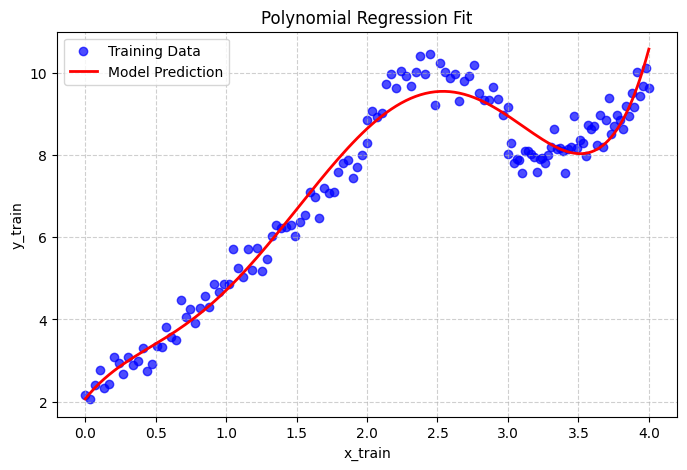

In [8]:
# 🔹 Create figure for data + prediction
plt.figure(figsize=(8, 5))

# 🔹 Scatter plot (original data)
plt.scatter(x_train, y_train, color="blue", label="Training Data", alpha=0.7)

# 🔹 Sort values for smooth curve
sorted_idx = np.argsort(x_train)
x_sorted = x_train[sorted_idx]
yp_sorted = yp[sorted_idx]

# 🔹 Plot prediction curve (smooth)
plt.plot(x_sorted, yp_sorted, color="red", label="Model Prediction", linewidth=2)
plt.xlabel("x_train")
plt.ylabel("y_train")
plt.title("Polynomial Regression Fit")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

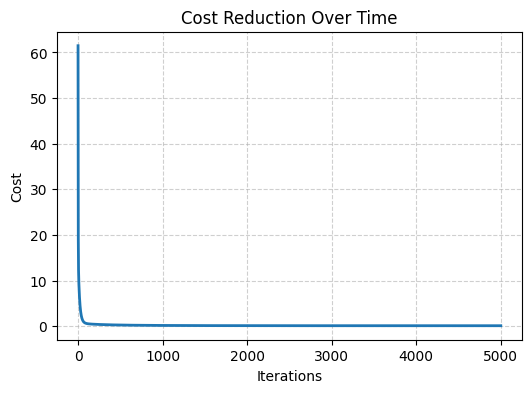

In [9]:
# Plot cost vs iterations
plt.figure(figsize=(6, 4))
plt.plot(cost_, linewidth=2)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Reduction Over Time")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()